# Quora Duplicate Questions — walkthrough

Given two questions, decide whether they're asking the same thing.
Classical ML: hand-engineered similarity features + bag-of-words, fed to a RandomForest.

**This notebook is the readable walkthrough, not the source of truth.**
The feature code lives in `features.py`, which `train.py` and `app.py` both import.
I import from it here too, so all three places can never disagree about how a
feature is computed. `train.py` is what actually saves the pickles.

Run this from the project root, with `train.csv` (Kaggle Quora Question Pairs) sitting there.

In [2]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

# the whole point: same preprocessing + same features as train.py and app.py
from features import preprocess, build_features, FEATURE_NAMES

SAMPLE_SIZE = 100000
CSV_PATH = "train.csv"

## 1. Load the data

100k rows out of the full ~400k. Sampling keeps this notebook runnable, and it's the
same `random_state=2` sample `train.py` uses, so the numbers here line up with the
model I actually ship.

In [3]:
df = pd.read_csv(CSV_PATH).sample(SAMPLE_SIZE, random_state=2)
df = df.dropna(subset=["question1", "question2"])
print(df.shape)
df.head()

(99999, 6)


,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


## 2. How balanced are the classes?

This matters more than it looks. If most pairs are non-duplicates, then a model that
blindly guesses "not duplicate" every time already scores that share — so I can't judge
anything by accuracy alone later on.

is_duplicate
0    0.632146
1    0.367854
Name: proportion, dtype: float64

guessing 'not duplicate' every time would score: 63.2%


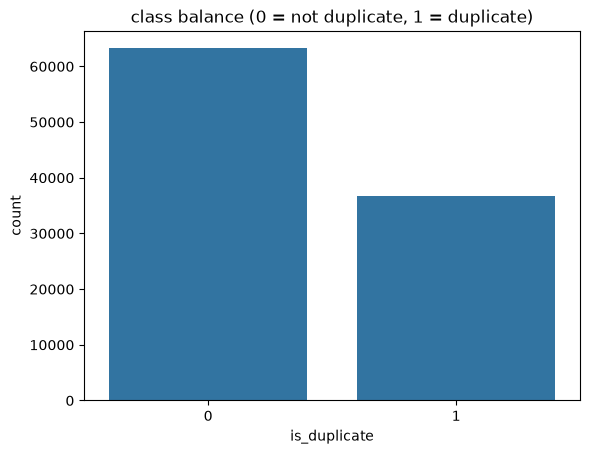

In [4]:
balance = df["is_duplicate"].value_counts(normalize=True)
print(balance)
print(f"\nguessing 'not duplicate' every time would score: {balance[0]:.1%}")

sns.countplot(x="is_duplicate", data=df)
plt.title("class balance (0 = not duplicate, 1 = duplicate)")
plt.show()

## 3. Preprocess

Lowercase, expand contractions, strip HTML and punctuation. The contraction step is the
important one: without it `"don't"` and `"do not"` look like completely different words,
so real overlap between two questions gets undercounted.

This is imported from `features.py` — the exact same function the Streamlit app calls on
user input at serve time. That's what stops training text and serving text from drifting apart.

In [5]:
print("BEFORE:", df["question1"].iloc[0])

df["question1"] = df["question1"].apply(preprocess)
df["question2"] = df["question2"].apply(preprocess)

print("AFTER: ", df["question1"].iloc[0])
df[["question1", "question2", "is_duplicate"]].head()

BEFORE: What is the best marketing automation tool for small and mid-size companies?


c:\Users\param\projects\quora-duplicate-questions-detection\features.py:196: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  q = BeautifulSoup(q, "html.parser").get_text()


AFTER:  what is the best marketing automation tool for small and mid size companies


,question1,question2,is_duplicate
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wh...,0
327711,i am from india and live abroad i met a guy f...,t i e t to thapar university to thapar univers...,0
367788,why do so many people in the u s hate the sou...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0


## 4. Build the 22 engineered features

Five groups, all measuring *how similar the two strings are* rather than what they say:

| Group | Count | Captures |
|---|---|---|
| Length & counts | 4 | raw size of each question |
| Word overlap | 3 | how many words the two share |
| Token ratios | 8 | overlap of non-stopwords / stopwords / all tokens, plus same first & last word |
| Length-derived | 3 | length gap, mean length, longest common substring |
| Fuzzy string match | 4 | edit-distance style similarity (`rapidfuzz`) |

I zip over the two columns instead of `df.iterrows()` — iterrows constructs a fresh
pandas Series per row, which on 100k rows is minutes of pure overhead.

In [6]:
engineered = np.array([
    build_features(q1, q2)
    for q1, q2 in zip(df["question1"], df["question2"])
])

y = df["is_duplicate"].values
print("engineered shape:", engineered.shape, "(expect 22 columns)")

pd.DataFrame(engineered, columns=FEATURE_NAMES[:22]).head()

engineered shape: (99999, 22) (expect 22 columns)


,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,csc_min,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,75.0,76.0,13.0,13.0,12.0,26.0,0.46,0.874989,0.874989,0.999980,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99.337748,98.666667,99.337748,99.337748
1,48.0,56.0,12.0,15.0,8.0,24.0,0.33,0.666644,0.499988,0.714276,...,0.466664,1.0,1.0,3.0,13.5,0.224490,69.230769,68.085106,66.666667,73.529412
2,104.0,119.0,26.0,20.0,4.0,38.0,0.11,0.000000,0.000000,0.428565,...,0.115384,0.0,0.0,6.0,23.0,0.047619,42.152466,42.780749,39.090909,46.408840
3,58.0,145.0,13.0,30.0,1.0,34.0,0.03,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,17.0,21.5,0.050847,37.438424,51.724138,38.000000,39.506173
4,34.0,49.0,5.0,9.0,3.0,13.0,0.23,0.749981,0.599988,0.000000,...,0.333330,1.0,0.0,4.0,7.0,0.542857,60.240964,74.074074,48.192771,69.230769


### Do these features actually separate the classes?

If a feature is worth keeping, duplicates and non-duplicates should sit at visibly
different values for it.

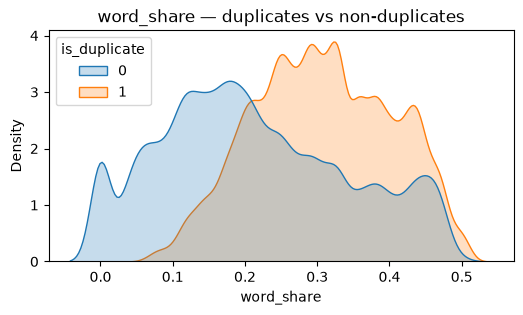

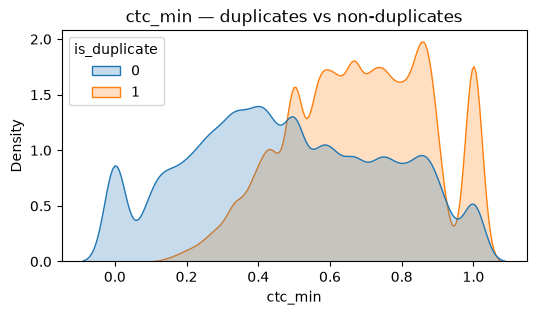

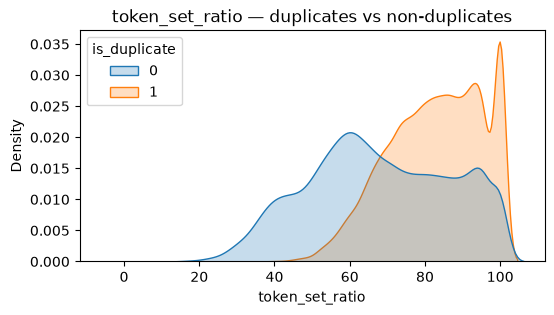

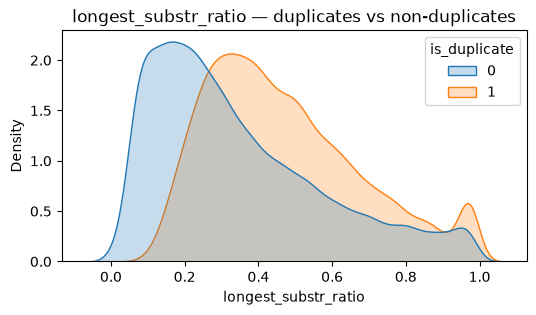

In [7]:
feat_df = pd.DataFrame(engineered, columns=FEATURE_NAMES[:22])
feat_df["is_duplicate"] = y

for col in ["word_share", "ctc_min", "token_set_ratio", "longest_substr_ratio"]:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(data=feat_df, x=col, hue="is_duplicate", common_norm=False, fill=True)
    plt.title(f"{col} — duplicates vs non-duplicates")
    plt.show()

## 5. Split BEFORE fitting the vectorizer

This ordering is the part that's easy to get wrong, and I did get it wrong in the first
version of this project.

If I fit `CountVectorizer` on the whole dataset and split afterwards, the 3000 words it
picks are chosen with knowledge of what ends up in the test set. Test vocabulary leaks
into training and the score comes out looking better than it honestly is.

So: split first, then fit the vectorizer on training questions only. `stratify=y` keeps
the duplicate ratio the same in both halves.

In [8]:
idx_train, idx_test, y_train, y_test = train_test_split(
    np.arange(len(df)), y, test_size=0.2, random_state=1, stratify=y
)

q1_all = df["question1"].values
q2_all = df["question2"].values

# fit on TRAIN questions only
cv = CountVectorizer(max_features=3000)
cv.fit(list(q1_all[idx_train]) + list(q2_all[idx_train]))

idf_transformer = TfidfTransformer()
idf_transformer.fit(cv.transform(list(q1_all[idx_train]) + list(q2_all[idx_train])))

print("vocabulary size:", len(cv.vocabulary_))
print("train rows:", len(idx_train), "| test rows:", len(idx_test))

vocabulary size: 3000
train rows: 79999 | test rows: 20000


## 6. The 23rd feature: tf-idf cosine similarity

The 22 features above count *how much* overlap there is, but treat every shared word as
equally meaningful. Two questions both containing "the" tells me nothing; both containing
"quaternion" tells me a lot.

**IDF (inverse document frequency)** is the knob that fixes this — it down-weights words
that appear everywhere and up-weights rare ones. Cosine similarity on those weighted
vectors gives one number: how similar are these two questions, judged by their *rare*
shared words.

Fitted on training data only, same as the vectorizer, for the same leakage reason.

In [9]:
def vectorize(indices):
    q1_bow = cv.transform(q1_all[indices]).toarray()
    q2_bow = cv.transform(q2_all[indices]).toarray()

    # cosine similarity for every row at once. a python loop over 80k rows
    # would be the slow way to compute exactly the same thing
    q1_tfidf = normalize(idf_transformer.transform(q1_bow))
    q2_tfidf = normalize(idf_transformer.transform(q2_bow))
    sims = np.asarray(q1_tfidf.multiply(q2_tfidf).sum(axis=1))

    return np.hstack((engineered[indices], sims, q1_bow, q2_bow))


X_train = vectorize(idx_train)
X_test = vectorize(idx_test)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("\ncolumn layout: [22 engineered] + [1 tfidf_cosine_sim] + [3000 q1 bow] + [3000 q2 bow] = 6023")

X_train: (79999, 6023)
X_test:  (20000, 6023)

column layout: [22 engineered] + [1 tfidf_cosine_sim] + [3000 q1 bow] + [3000 q2 bow] = 6023


## 7. Train

`max_depth=50` caps how deep the trees grow. That's mostly a deployment constraint rather
than an ML one — an uncapped forest on this much data pickles out to hundreds of MB, and
GitHub hard-rejects any file over 100MB, so the app could never load it.

`n_jobs=-1` uses all cores. `random_state=42` so re-running gives the same forest.

In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print("trained")

trained


## 8. Evaluate — and not just on accuracy

Accuracy on its own is misleading here, because of the class imbalance from section 2.
The classification report splits performance per class, and the confusion matrix shows
*which direction* the mistakes go — whether I'm missing real duplicates (false negatives)
or flagging unrelated questions as duplicates (false positives).

In [11]:
y_pred = rf.predict(X_test)

print("accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(f"(vs {(y_test == 0).mean():.1%} for always guessing 'not duplicate')\n")
print(classification_report(y_test, y_pred, target_names=["not duplicate", "duplicate"]))

accuracy: 0.7978
(vs 63.2% for always guessing 'not duplicate')

               precision    recall  f1-score   support

not duplicate       0.83      0.85      0.84     12643
    duplicate       0.73      0.71      0.72      7357

     accuracy                           0.80     20000
    macro avg       0.78      0.78      0.78     20000
 weighted avg       0.80      0.80      0.80     20000



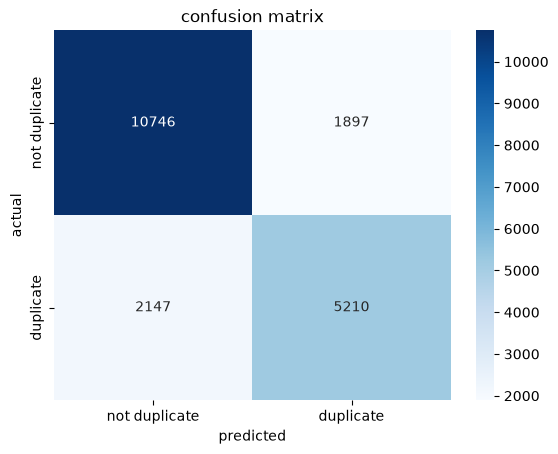

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["not duplicate", "duplicate"],
            yticklabels=["not duplicate", "duplicate"])
plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("confusion matrix")
plt.show()

## 9. Which features did the forest actually lean on?

`FEATURE_NAMES` covers the first 23 columns; the remaining 6000 are individual
bag-of-words counts, which I leave unnamed.

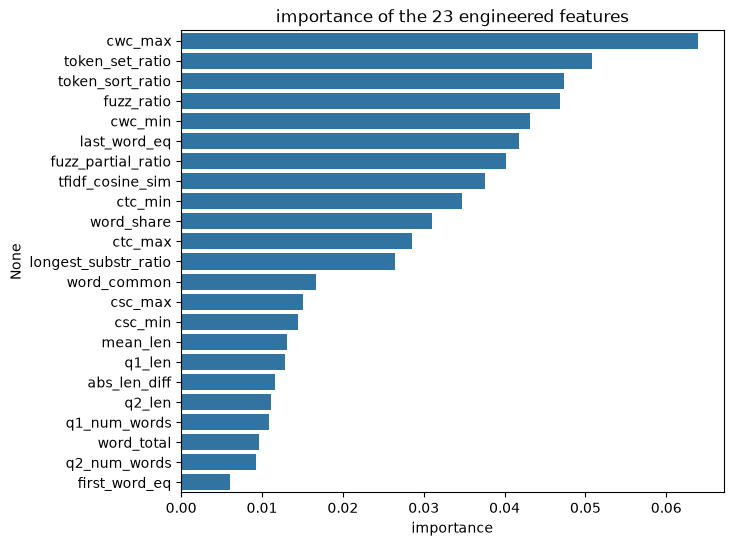

the 23 engineered features account for 62.3% of total importance, the 6000 bag-of-words columns for the rest


In [13]:
importances = rf.feature_importances_[:23]
imp = pd.Series(importances, index=FEATURE_NAMES).sort_values(ascending=False)

plt.figure(figsize=(7, 6))
sns.barplot(x=imp.values, y=imp.index)
plt.title("importance of the 23 engineered features")
plt.xlabel("importance")
plt.show()

print(f"the 23 engineered features account for {importances.sum():.1%} "
      f"of total importance, the 6000 bag-of-words columns for the rest")

## 10. Sanity check the serving path

The original bug in this project was that the app built its feature vector differently
from training — wrong count, wrong order, and skipping preprocessing entirely. So the
last thing I do is call the *exact function the Streamlit app calls* and confirm it
produces a vector the model accepts.

`make_input_vector` takes two **raw** questions and does preprocess → 22 features →
tf-idf similarity → bag-of-words → stack, all in one place.

In [14]:
from features import make_input_vector

pairs = [
    ("How do I learn Python?", "What is the best way to learn Python?"),
    ("What is the capital of France?", "How do I bake bread?"),
    ("Don't you think AI is dangerous?", "Do you not think AI is dangerous?"),
]

for q1, q2 in pairs:
    vec = make_input_vector(q1, q2, cv, idf_transformer)
    assert vec.shape[1] == rf.n_features_in_, "serving vector doesn't match training shape!"
    pred = rf.predict(vec)[0]
    proba = rf.predict_proba(vec)[0][1]
    print(f"{'DUPLICATE' if pred == 1 else 'NOT DUP  '}  (p={proba:.2f})   {q1}  ||  {q2}")

print("\nserving path matches training shape")

DUPLICATE  (p=0.64)   How do I learn Python?  ||  What is the best way to learn Python?
NOT DUP    (p=0.01)   What is the capital of France?  ||  How do I bake bread?
DUPLICATE  (p=0.70)   Don't you think AI is dangerous?  ||  Do you not think AI is dangerous?

serving path matches training shape


The third pair only comes out as a duplicate because `preprocess` expands `"Don't"`
into `"do not"` before anything else runs. That single step is what makes training text
and serving text look the same.

---

## What I'd do differently

- **A held-out validation split.** Right now the test set is the only thing I check
  against, so any tuning I do against it slowly leaks into the choice of model.
- **Try TF-IDF vectors in place of raw counts** for the 6000 bag-of-words columns, not
  just for the similarity feature.
- **The 6000 bag-of-words columns dwarf the 23 engineered ones**, and the importance plot
  above suggests the engineered features carry a lot of the signal. Worth testing whether
  a much smaller vocabulary loses anything — a far smaller model pickle if not.

## Where things live

- `features.py` — preprocessing + all feature code (imported here, by `train.py`, and by `app.py`)
- `train.py` — trains and saves `random_forest_model.pkl`, `count_vectorizer.pkl`, `idf_transformer.pkl`
- `app.py` — Streamlit UI